<a href="https://colab.research.google.com/github/josedanielisidororeyes/Natural_Language_Processing/blob/main/Tarea_Embeddings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Nombre del Alumno: José Daniel Isidoro Reyes
## Matrícula: 261552
## Nombre de la Tarea: Ejercicios de representación de texto (embeddings)
## Fecha: 13/03/2026

In [33]:
# Carga de librerías
import pandas as pd
import numpy as np
import re
import nltk
import unicodedata

try:
    from gensim.models import Word2Vec
except:
    !pip install gensim
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Descarga de recursos necesarios para NLTK
nltk.download('punkt')
nltk.download('stopwords')
from nltk.corpus import stopwords
stop_words = set(stopwords.words('spanish'))

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## Carga de Datos

In [34]:
# Carga de Datos
df =  pd.read_csv('/content/drive/MyDrive/Procesamiento del Lenguaje Natural/Ejercicios de Representación de textos - Embeddings.csv')

# Visualización de primeras filas
print(f"Total de tweets cargados: {len(df)}")
df.head()


Total de tweets cargados: 148


,frase
0,La ciberseguridad protege la información digit...
1,La inteligencia artificial transforma múltiple...
2,"El baloncesto combina velocidad, técnica y tra..."
3,El hardware y el software son complementarios ...
4,La democracia permite la participación ciudada...


Se observa que el conjunto de datos está limpios (no emoticos, menciones, correos, urls, etc). Por lo tanto, procedemos a realizar preprocesamiento mínimo.

## Preprocesamiento de Texto

In [36]:
oraciones  =  []
for texto in df['frase']:
    # Eliminación de acentos
    texto_norm  =  unicodedata.normalize('NFKD', texto).encode('ascii', 'ignore').decode('utf-8')
    # Conversión a minúsculas
    palabras =  texto_norm.lower().replace('.', '').replace(',', '').split()
    # Eliminación de stopwords
    tokens  = [w for w in palabras if w not in stop_words and len(w) > 2]
    oraciones.append(tokens)

print("Primeros  tokens generados:")
print(oraciones[0])



Primeros  tokens generados:
['ciberseguridad', 'protege', 'informacion', 'digital']


Se realiza preprosamiento de texto básico, el cual incluye conversión a minúsculas y  eliminación de acentos, puntos y stopwords.

## Entranamiento del Modelo (Skip-gram)

In [61]:
modelo_w2v  =  Word2Vec(sentences =  oraciones,
                        vector_size =  10,
                        window  =  8,
                        min_count =  2,
                        sg =  1,
                        seed =  42,
                        epochs = 100
                        )

print("Modelo entrenado exitosamente!")

Modelo entrenado exitosamente!


Se entrena un modelo Word2Vec utilizando la arquitectura Skip-gram, la cual busca predecir el contexto (las 5 palabras vecinas definidas en window=5) a partir de una palabra central para aprender sus relaciones semánticas.

## Selección  de palabras para visualización

In [62]:
palabras_visualizar = [
    "ciberseguridad", "digital", "inteligencia", "artificial", "algoritmos",
    "software", "hardware", "baloncesto", "natacion", "futbol", "deporte",
    "atletas", "democracia", "politicos", "elecciones", "derecho"
]

# Obtención de vectores de Word2Vec
X_w2v =  np.array([modelo_w2v.wv[word] for word in palabras_visualizar if word in modelo_w2v.wv])
palabras_filtradas =  [word for word in palabras_visualizar if word in modelo_w2v.wv]

# Visualización de Embeddings

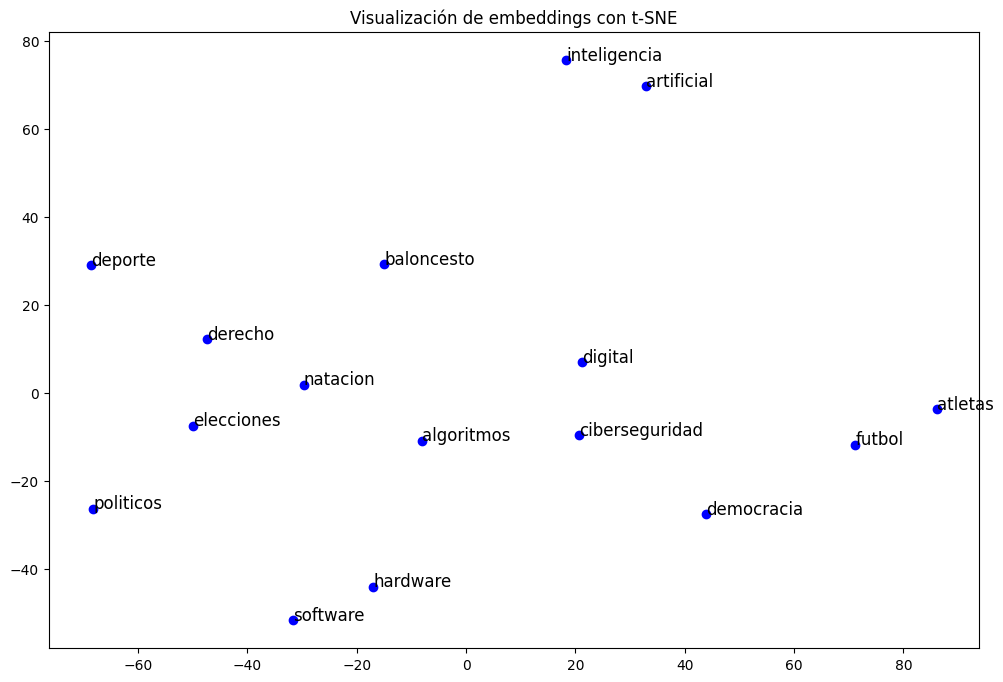

In [63]:
# Reducción de dimensionalidad}
tsne =  TSNE(n_components =  2, random_state = 42, perplexity= 5, init = 'pca')
X_2d = tsne.fit_transform(X_w2v)

# Visualización de Embedding
plt.figure(figsize =  (12, 8))
for i, palabra in enumerate(palabras_filtradas):
    x, y =  X_2d[i, 0], X_2d[i, 1]
    plt.scatter(x, y, c = "blue")
    plt.text(x + 0.02, y + 0.02, palabra, fontsize=12)

plt.title("Visualización de embeddings con t-SNE")
plt.show()


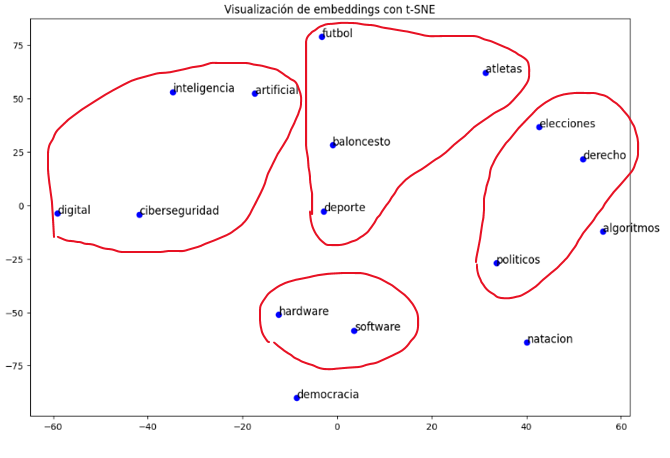

De manera general se idenfican los siguientes 4 grupos:

*   Deportes [futbol, atletas, baloncesto, deporte]
*   Tecnologico [inteligencia, artificial, digital, ciberseguridad]
*   Sociales [politicos, eleccions, derecho]
*   Infraestructura [hardware, software]

Finalmente, llama la atención la palabra algoritmos, la cual se encuentra lejos del grupo tecnologico o infraestructura. Al  igual que natación que está lejos de deportes, lo cual sugiere que se usaron en contexto diferentes.